# Regresion Polinomial con el dataset Auto MPG

El dataset **Auto MPG** contiene informacion sobre el consumo de combustible de automoviles de los anos 70 y 80. Usaremos los **caballos de fuerza (horsepower)** para predecir las **millas por galon (mpg)**.

La relacion entre estas dos variables no es lineal: a mas caballos de fuerza, menos eficiencia, pero la caida no es constante sino que se aplana. Una curva polinomial describe esto mucho mejor que una linea recta.

---

## Paso 1: Importar las bibliotecas necesarias

Antes de hacer cualquier cosa, necesitamos cargar las herramientas que vamos a usar.

- `pandas`: para cargar y manipular tablas de datos
- `numpy`: para operaciones matematicas con arrays de numeros
- `matplotlib.pyplot`: para hacer graficas
- `PolynomialFeatures`: transforma x en [x, x^2, x^3...] segun el grado que elijas
- `LinearRegression`: encuentra los coeficientes optimos usando minimos cuadrados
- `train_test_split`: divide los datos en entrenamiento y prueba
- `r2_score` y `mean_squared_error`: para medir que tan bueno es el modelo

Escribe los imports en la celda de abajo y ejecutala.

In [1]:
# Importa aqui todas las bibliotecas necesarias
# pandas, numpy, matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# desde sklearn.preprocessing importa PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures
# desde sklearn.linear_model importa LinearRegression
from sklearn.linear_model import LinearRegression
# desde sklearn.model_selection importa train_test_split
from sklearn.model_selection import train_test_split
# desde sklearn.metrics importa r2_score y mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error

## Paso 2: Cargar el dataset

El dataset Auto MPG esta disponible publicamente en este URL:

```
https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data
```

El archivo no tiene encabezados, asi que debes asignarlos manualmente. Las columnas son:
`['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']`

Ademas, los valores faltantes en este archivo estan marcados con el texto `?` en lugar de estar vacios, por lo que debes indicarle a pandas que trate `?` como valor nulo al momento de cargar.

Usa `pd.read_csv()` con los parametros:
- `sep='\s+'` para separar por espacios
- `names=` para asignar los nombres de columna
- `na_values='?'` para que pandas reconozca los signos de interrogacion como valores nulos

Luego imprime las primeras 5 filas con `.head()` para verificar que se cargo bien.

In [12]:
# URL del dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

# Nombres de columnas (el archivo no los tiene)
columnas = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year', 'origin', 'car_name']

# Carga el dataset con pd.read_csv usando los parametros indicados arriba
df = pd.read_csv(url, sep=r'\s+', names=columnas, na_values='?')


# Imprime las primeras 5 filas
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## Paso 3: Explorar y limpiar los datos

Antes de entrenar cualquier modelo, siempre debes entender bien los datos que tienes.

Haz lo siguiente:

1. Imprime el tamaño del dataset con `.shape` (cuantas filas y columnas tiene)
2. Revisa los tipos de datos de cada columna con `.dtypes`
3. Cuenta cuantos valores nulos hay en cada columna con `.isnull().sum()`
4. Elimina las filas con valores nulos usando `.dropna()` y guarda el resultado en el mismo dataframe
5. Vuelve a imprimir `.shape` para ver cuantas filas quedaron despues de limpiar

Nota: la columna `horsepower` probablemente aparece como tipo `object` (texto) en lugar de numero, por culpa de los `?` que habia en el archivo original. Al usar `na_values='?'` y luego `dropna()`, pandas deberia poder convertirla. Si no es asi, usa `pd.to_numeric()` para forzar la conversion.

In [13]:
# 1. Imprime el tamaño del dataset
print(df.shape)

(398, 9)


In [14]:
# 2. Revisa los tipos de datos
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name            str
dtype: object


In [15]:
# 3. Cuenta los valores nulos por columna
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [16]:
# 4. Elimina las filas con valores nulos
df = df.dropna()

In [19]:
# 5. Convierte horsepower a numero por si quedo como texto
df['horsepower'] = pd.to_numeric(df['horsepower'])


In [18]:
# 6. Vuelve a imprimir el tamaño para ver cuantas filas quedaron
print(df.shape)

(392, 9)


## Paso 4: Visualizar la relacion entre horsepower y mpg

Antes de entrenar cualquier modelo, grafica los datos crudos para entender visualmente la relacion entre las dos variables.

Haz un grafico de dispersion (scatter plot) con:
- Eje x: `horsepower`
- Eje y: `mpg`
- Agrega etiquetas a los ejes y un titulo

Observa la forma de la nube de puntos. Preguntate: podria una linea recta describir bien esta relacion? O la forma sugiere una curva?

Si la nube baja rapido al principio y luego se aplana, eso es una pista clara de que necesitas al menos un termino x^2.

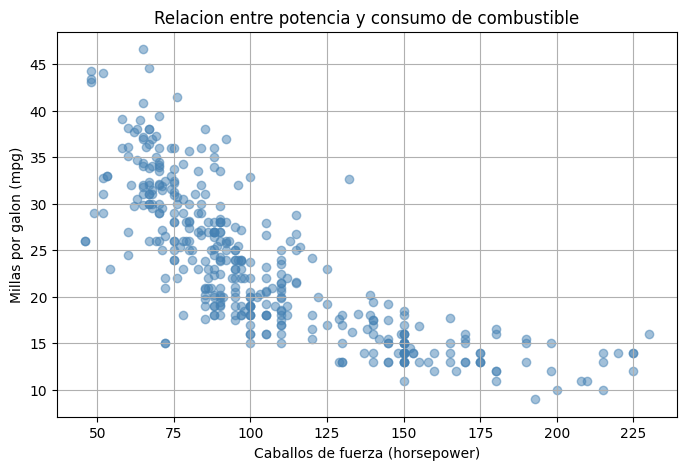

In [20]:
# Crea un grafico de dispersion de horsepower vs mpg
plt.figure(figsize=(8, 5))
# Usa plt.scatter(), agrega etiquetas con plt.xlabel(), plt.ylabel()
plt.scatter(df['horsepower'], df['mpg'], alpha=0.5, color='steelblue')
plt.xlabel('Caballos de fuerza (horsepower)')
plt.ylabel('Millas por galon (mpg)')
# y un titulo con plt.title()
plt.title('Relacion entre potencia y consumo de combustible')
# Termina con plt.show()
plt.grid(True)
plt.show()


## Paso 5: Preparar los datos para el modelo

Ahora prepara los datos para entrenar el modelo.

1. Crea la variable `X` con solo la columna `horsepower`. Usa doble corchete `[['horsepower']]` para que quede como un array de dos dimensiones, que es lo que espera sklearn.
2. Crea la variable `y` con la columna `mpg`.
3. Divide los datos en entrenamiento (80%) y prueba (20%) usando `train_test_split`. Usa `random_state=42` para que los resultados sean reproducibles cada vez que ejecutes el notebook.
4. Imprime el tamaño de cada conjunto para verificar la division.

Los datos de prueba los guardas a un lado y no los vuelves a tocar hasta el paso de evaluacion. Simulas que esos datos son del futuro y todavia no los conoces.

In [21]:
# 1. Variable de entrada (horsepower)
X = df[['horsepower']]

# 2. Variable objetivo (mpg)
y = df['mpg']

# 3. Divide en entrenamiento y prueba (80/20, random_state=42)
# Division 80% entrenamiento, 20% prueba
# random_state=42 garantiza que siempre obtengas la misma division
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Imprime el tamaño de cada conjunto
print(f'Entrenamiento: {X_train.shape[0]} filas')
print(f'Prueba:        {X_test.shape[0]} filas')

Entrenamiento: 313 filas
Prueba:        79 filas


## Paso 6: Entrenar modelos con distintos grados y comparar

Este es el paso central. Vamos a probar grados del 1 al 5 y medir el error de cada uno.

Para cada grado, el proceso es:

1. Crear un objeto `PolynomialFeatures(degree=grado, include_bias=False)`. Esto transforma tu columna horsepower en multiples columnas: [horsepower, horsepower^2, horsepower^3...]. Desactivamos el bias ya que LinearRegression de sklearn ya agrega ese termino constante por su cuenta de forma automatica. Lo llama intercept_.
2. Transformar X_train y X_test con `.fit_transform()` y `.transform()` respectivamente. Nota: el `fit` solo se hace sobre entrenamiento para no contaminar la evaluacion con informacion de los datos de prueba.
3. Crear y entrenar un modelo `LinearRegression()` con los datos de entrenamiento transformados.
4. Predecir sobre entrenamiento y sobre prueba.
5. Calcular R2 y RMSE para ambos conjuntos. El RMSE es la raiz cuadrada del mean_squared_error.
6. Guardar los resultados.

Guarda los resultados en una lista o en un diccionario para luego imprimirlos como tabla.

In [22]:
# Lista para guardar los resultados de cada grado
resultados = []

# Itera sobre los grados del 1 al 5
for grado in range(1, 6):
    
    # 1. Crea el transformador polinomial para este grado
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    
    # 2. Transforma X_train y X_test
    # Usa fit_transform sobre X_train y solo transform sobre X_test
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)
    
    # 3. Crea y entrena el modelo de regresion lineal
    modelo = LinearRegression()
    modelo.fit(X_train_poly, y_train)
    
    # 4. Predice sobre entrenamiento y prueba
    pred_train = modelo.predict(X_train_poly)
    pred_test  = modelo.predict(X_test_poly)
    
    # 5. Calcula R2 y RMSE para entrenamiento
    r2_train   = r2_score(y_train, pred_train)
    rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
    # 6. Calcula R2 y RMSE para prueba
    r2_test    = r2_score(y_test, pred_test)
    rmse_test  = mean_squared_error(y_test, pred_test) ** 0.5
    # 7. Guarda los resultados en la lista
    # Formato sugerido: {'grado': grado, 'r2_train': ..., 'r2_test': ..., 'rmse_train': ..., 'rmse_test': ...}
    resultados.append({
        'grado'     : grado,
        'r2_train'  : round(r2_train, 4),
        'r2_test'   : round(r2_test, 4),
        'rmse_train': round(rmse_train, 4),
        'rmse_test' : round(rmse_test, 4)
    })

# Imprime los resultados como tabla usando pd.DataFrame(resultados)
pd.DataFrame(resultados)

,grado,r2_train,r2_test,rmse_train,rmse_test
0,1,0.6121,0.5660,4.9472,4.7067
1,2,0.6956,0.6392,4.3823,4.2915
2,3,0.6758,0.6293,4.5227,4.3500
3,4,0.6292,0.5935,4.8369,4.5552
4,5,0.5690,0.5412,5.2152,4.8390


## Analizar los resultados

Observa la tabla del paso anterior y responde estas preguntas en una celda de texto (puedes hacer doble clic en esta celda para editarla y escribir tus respuestas):

1. En que grado el error de prueba (rmse_test) es minimo?
2. A partir de que grado el error de prueba empieza a subir aunque el de entrenamiento siga bajando? Ese es el punto de sobreajuste.
3. El modelo de grado 1 (linea recta) tiene un error mucho mayor que los demas? Eso indicaria subajuste.

**Escribe tus respuestas aqui:**

- Grado con menor error de prueba:
- Punto donde empieza el sobreajuste:
- Hay subajuste en grado 1?

## Paso 7: Visualizar el modelo ganador

Con el grado que obtuvo el mejor resultado en prueba, vamos a graficar la curva ajustada sobre los puntos originales.

1. Elige el grado ganador (el que tuvo menor rmse_test en el paso 6).
2. Entrena el modelo final con ese grado usando todos los datos de entrenamiento (ya lo tienes del loop anterior, puedes re-entrenarlo aqui para que sea explicito).
3. Crea un array de valores de x espaciados uniformemente entre el minimo y maximo de horsepower usando `np.linspace()`.
4. Transforma ese array con PolynomialFeatures y predice con el modelo.
5. Grafica los puntos originales en gris y la curva ajustada en azul.

La curva debe seguir la forma general de los datos sin zigzaguear entre los puntos.

c:\Users\Flor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


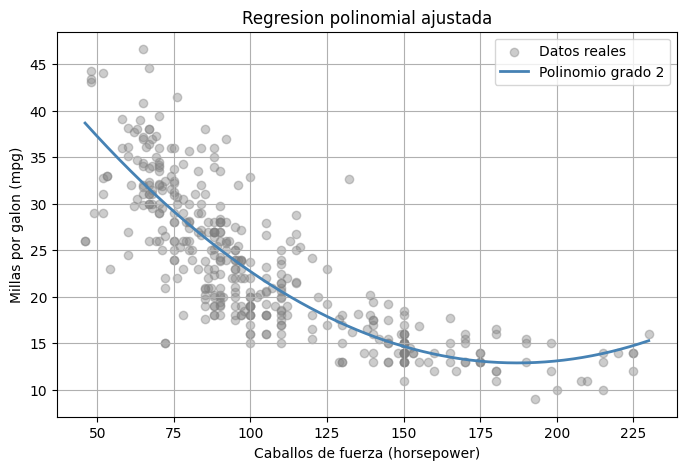

In [23]:
# Elige el grado ganador segun los resultados del paso 6
grado_ganador = 2  # cambia este valor segun lo que encontraste

# 1. Crea el transformador y entrena el modelo final con ese grado
poly_final   = PolynomialFeatures(degree=grado_ganador, include_bias=False)
X_train_poly = poly_final.fit_transform(X_train)
modelo_final = LinearRegression()
modelo_final.fit(X_train_poly, y_train)

# 2. Crea un array de x para dibujar la curva suavemente
# Usa np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
x_curva      = np.linspace(X['horsepower'].min(), X['horsepower'].max(), 300).reshape(-1, 1)

# 3. Transforma ese array y predice con el modelo
x_curva_poly = poly_final.transform(x_curva)
y_curva      = modelo_final.predict(x_curva_poly)

# 4. Grafica los puntos originales y la curva
plt.figure(figsize=(8, 5))
# plt.scatter() para los puntos originales
plt.scatter(df['horsepower'], df['mpg'], alpha=0.4, color='gray', label='Datos reales')
# plt.plot() para la curva
plt.plot(x_curva, y_curva, color='steelblue', linewidth=2, label=f'Polinomio grado {grado_ganador}')
# Agrega etiquetas, titulo y leyenda
plt.xlabel('Caballos de fuerza (horsepower)')
plt.ylabel('Millas por galon (mpg)')
plt.title('Regresion polinomial ajustada')
plt.legend()
plt.grid(True)
plt.show()


## Paso 8: Interpretar los coeficientes

Imprime los coeficientes del modelo ganador. El modelo entrenado tiene dos atributos:

- `modelo.intercept_`: el valor de a0 (la constante, termino independiente)
- `modelo.coef_`: un array con los coeficientes de x, x^2, x^3...

Imprimelos e interpreta cada uno:
- Si el coeficiente de x^2 es negativo, la parabola abre hacia abajo, lo que tiene sentido: a mas caballos de fuerza, menos eficiencia, pero la caida es cada vez mas lenta.
- El coeficiente de x^1 indica la inclinacion inicial de la curva.
- La constante (a0) indica donde empieza la curva matematicamente (puede ser negativa y no tener sentido fisico directo).

In [24]:
# Imprime el intercepto (a0)
print(f'Intercepto (a0): {modelo_final.intercept_:.4f}')
# Imprime los coeficientes (a1, a2, a3... segun el grado)
print(f'Coeficientes:    {modelo_final.coef_}')

Intercepto (a0): 58.2129
Coeficientes:    [-0.48445839  0.0012949 ]


## Paso 9: Hacer predicciones con el modelo

Ahora usa el modelo para predecir el consumo de combustible de autos con distintas potencias. Esto muestra que una vez entrenado el modelo, puedes obtener un valor de mpg para cualquier horsepower que quieras, incluso valores que no estaban en el dataset.

Predice el mpg para:
- Un auto con 70 caballos de fuerza
- Un auto con 100 caballos de fuerza
- Un auto con 150 caballos de fuerza
- Un auto con 200 caballos de fuerza

Recuerda que para predecir debes transformar el valor con PolynomialFeatures antes de pasarlo al modelo, exactamente igual que hiciste con los datos de entrenamiento.

Despues de obtener las predicciones, reflexiona: tienen sentido? A mayor horsepower, el mpg predicho es menor? Es consistente con lo que muestra la grafica?

In [36]:
# Valores de horsepower para los que quieres predecir
autos_nuevos = pd.DataFrame({
    'horsepower': [70, 100, 150, 200]
})

# Transforma los valores con PolynomialFeatures
autos_poly = poly_final.transform(autos_nuevos)

# Predice el mpg para cada auto
predicciones = modelo_final.predict(autos_poly)


# Imprime los resultados de forma legible
# Ejemplo: "Auto con 70 hp -> prediccion: X.XX mpg"
for hp, mpg_pred in zip(autos_nuevos['horsepower'], predicciones):
    print(f'Auto con {hp} hp -> {mpg_pred:.1f} mpg predichos')

Auto con 70 hp -> 30.6 mpg predichos
Auto con 100 hp -> 22.7 mpg predichos
Auto con 150 hp -> 14.7 mpg predichos
Auto con 200 hp -> 13.1 mpg predichos
